In [1]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
from sklearn.datasets import make_classification

2026-04-16 17:39:52.734695: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed = 128
np.random.seed(seed)

In [3]:
data, labels = make_classification(n_samples=2500,
                                   n_features=2,n_redundant=0,
                                   weights=[0.2,0.8], class_sep=0.5, 
                                   random_state=seed)

i:0


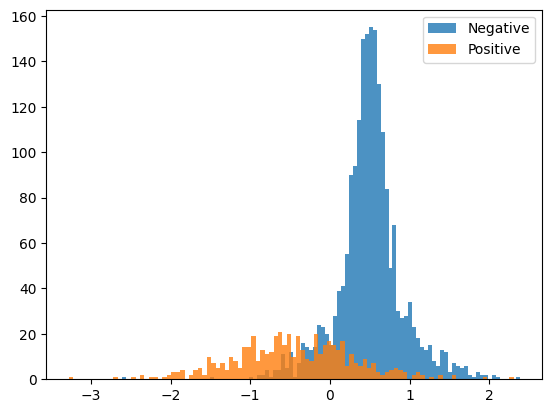

i:1


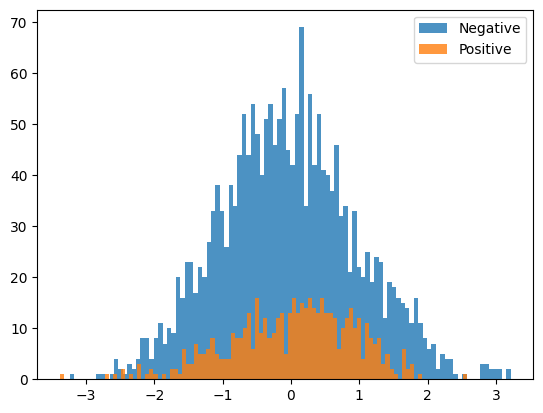

In [4]:
import matplotlib.pyplot as plt
for i in range(2):
    print(f'i:{i}')
    plt.hist(data[:,i][labels == 1], bins=100,alpha=0.8, label='Negative')
    plt.hist(data[:,i][labels == 0], bins=100,alpha=0.8, label='Positive')
    plt.legend()
    plt.show()

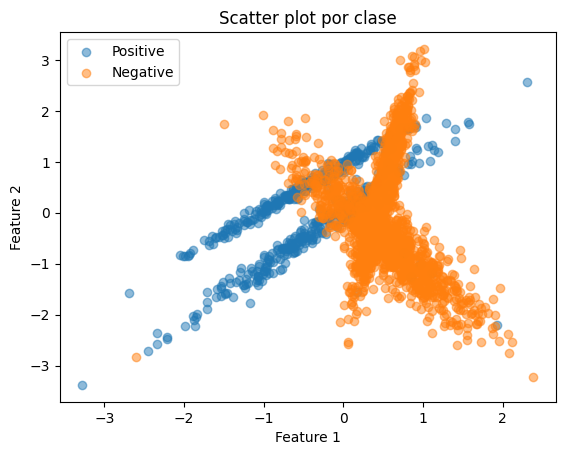

In [5]:
import matplotlib.pyplot as plt

# clase 0
plt.scatter(data[labels == 0, 0], # eje x
            data[labels == 0, 1], # eje y
            alpha=0.5, label='Positive')

# clase 1
plt.scatter(data[labels == 1, 0], 
            data[labels == 1, 1], 
            alpha=0.5, label='Negative')

plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter plot por clase')
plt.show()

In [6]:
# separamos la base de datos en subconjunto de entrenamiento (80%), subconjunto de validacion (10%) y subconjunto de prueba(10%)
from sklearn.model_selection import train_test_split

# dividir en base de datos de entrenamiento y de prueba
x_tr, x_test, y_tr, y_test = train_test_split(data, labels, train_size=0.8, shuffle=True)

# se divide el actual subconjunto de prueba en dos: subconjunto de prueba y subconjunto de validacion
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, train_size=0.5, shuffle=True)

In [7]:
# el modelo va a constar de:
#   1) capa de inputs con 2 neuronas (hay 2 inputs)
#   2) 3 capas intermedias (ocultas) de 8, 16 y 8 neuronas respectivamente
#   3) una capa de salida con 1 neurona (1 output)
# se define con un modelo secuencial de Keras

tf.random.set_seed(seed=seed)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),   # define los 2 inputs
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(16, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
# se crea el modelo y se almacena en el objeto de clase Sequential

In [8]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313 (1.22 KB)

 Trainable params: 313 (1.22 KB)

 Non-trainable params: 0 (0.00 B)

None


In [9]:
# antes de entrenar el modelo debemos compilarlo -> asociarlo con un
# algoritmo de optimizacion y una funcion de perdida
opt = tf.keras.optimizers.Adam()
lossf = tf.keras.losses.BinaryCrossentropy()
model.compile(optimizer=opt, loss=lossf)

In [10]:
# entrenamos el modelo
history = model.fit(x_tr, y_tr, validation_data=(x_val,y_val), 
                    epochs=9, batch_size=None)

Epoch 1/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5245 - val_loss: 0.3350
Epoch 2/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3396 - val_loss: 0.2538
Epoch 3/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3119 - val_loss: 0.2393
Epoch 4/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3051 - val_loss: 0.2346
Epoch 5/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3014 - val_loss: 0.2319
Epoch 6/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2979 - val_loss: 0.2294
Epoch 7/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2939 - val_loss: 0.2268
Epoch 8/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2894 - val_loss: 0.2241
Epoch 9/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2846 - val_loss: 0.2212


In [11]:
print(history.history)

{'loss': [0.5245233774185181, 0.3396478593349457, 0.3119359314441681, 0.30514973402023315, 0.3014478385448456, 0.29788708686828613, 0.29390034079551697, 0.28936997056007385, 0.284637987613678], 'val_loss': [0.3349789083003998, 0.25384190678596497, 0.23926550149917603, 0.2346470057964325, 0.23187191784381866, 0.22940492630004883, 0.22682839632034302, 0.22405169904232025, 0.2212168127298355]}


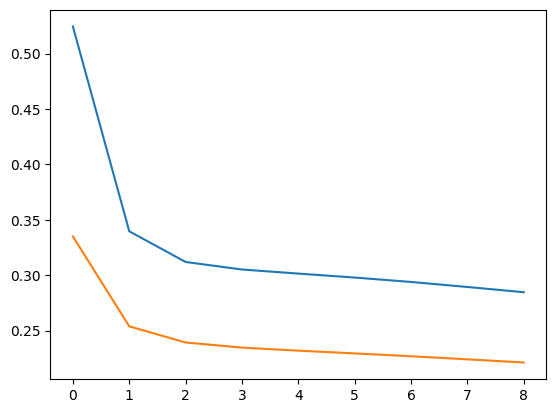

In [12]:
# graficamos la evolucion de las perdidas de entrenamiento y validacion a lo largo de las iteraciones
loss_list = history.history['loss']
val_loss_list = history.history['val_loss']
iterations = list(range(len(loss_list)))
plt.plot(iterations, loss_list)
plt.plot(iterations, val_loss_list)

plt.show()

In [13]:
# si queremos que el entrenamiento pare cuando la perdida no este mejorando
# en este ejemplo paramos si cada 3 epochs consecutivos la perdida no ha 
# disminuido al menos 0.001
early_stp = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, min_delta=0.001)

# se añade la parada temprana (opcional) y se aumenta el numero de epochs para ver
# como se da la parada temprana
history2 = model.fit(x_tr, y_tr, validation_data=(x_val,y_val), 
                    epochs=30, batch_size=None, callbacks=[early_stp])

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2802 - val_loss: 0.2186
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2765 - val_loss: 0.2164
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2735 - val_loss: 0.2147
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2711 - val_loss: 0.2133
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2693 - val_loss: 0.2123
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2678 - val_loss: 0.2115
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2666 - val_loss: 0.2109
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2656 - val_loss: 0.2104
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2647 - val_loss: 0.2099
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2638 - val_loss: 0.2095
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2630 - val_loss: 0.2089
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2623 - val_lo

En este punto ya hemos entrenado el modelo

In [14]:
# El modelo nos devuelve valores continuos entre 0 y 1 -> para obtener una 
# salida discreta (0 o 1) hemos de establecer un umbral (se establece en 0.5)
output = model.predict(x_test)
result = (output > 0.5).astype(float)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Keras divide x_test en batches (lotes).
El mensaje 8/8 significa:
8 batches procesados de 8 totales

In [ ]:
# estimacion laplaciana de los valores clasificados correctamente
from sklearn.metrics import accuracy_score
print(accuracy_score(result,y_test))

0.92


In [ ]:
# numero de elementos clasificados como:
#   positivos reales | falsos negativos
#   falsos positivos | negativos reales
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true=y_test, y_pred=result)

array([[ 26,  18],
       [  2, 204]])

In [ ]:
# varios parametros que estiman el rendimiento del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_true=y_test, y_pred=result))

              precision    recall  f1-score   support

           0       0.93      0.59      0.72        44
           1       0.92      0.99      0.95       206

    accuracy                           0.92       250
   macro avg       0.92      0.79      0.84       250
weighted avg       0.92      0.92      0.91       250



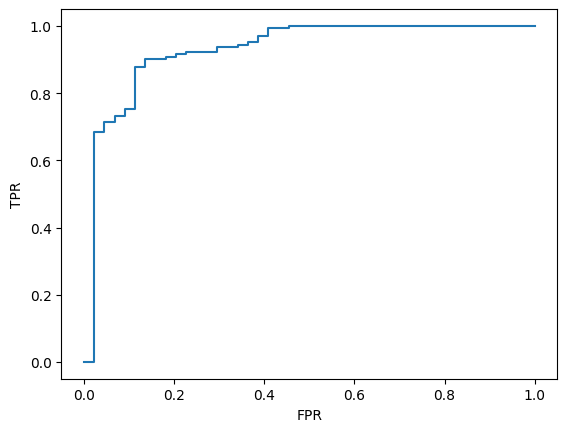

In [21]:
# se obtiene la curva ROC: indica en funcion del umbral para clasificar
# los elementos como positivos o negativos, los valores para los parametros
# fpr = positivos reales identificados entre todos los positivos reales
# tpr = negativos identificados como positivos entre todos los negativos reales
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, output)
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()